In [37]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore (1).csv


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [39]:
import os
print(os.listdir())

['.config', 'Sample - Superstore (1).csv', 'Sample - Superstore.csv', 'sample_data']


In [40]:
print(df.columns.tolist())
print("\n")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City       

In [41]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Order Year'] = df['Order Date'].dt.year
df['Order Month']= df['Order Date'].dt.month_name()
print("Date range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("\nKey metrics:")
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Total Orders:{df['Order ID'].nunique()}")
print(f"TotalCustomers:{df['Customer ID'].nunique()}")


Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00

Key metrics:
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders:5009
TotalCustomers:793


In [42]:
print("test")


test


In [43]:
monthly_sales = df.groupby(['Order Year','Order Month'])['Sales'].sum()
monthly_sales

Order Year  Order Month
2014        April           28295.3450
            August          27909.4685
            December        69545.6205
            February         4519.8920
            January         14236.8950
            July            33946.3930
            June            34595.1276
            March           55691.0090
            May             23648.2870
            November        78628.7167
            October         31453.3930
            September       81777.3508
2015        April           34195.2085
            August          36898.3322
            December        74919.5212
            February        11951.4110
            January         18174.0756
            July            28765.3250
            June            24797.2920
            March           38726.2520
            May             30131.6865
            November        75972.5635
            October         31404.9235
            September       64595.9180
2016        April           38750.0390
            August          31115.3743
            December        96999.0430
            February        22978.8150
            January         18542.4910
            July            39261.9630
            June            40344.5340
            March           51715.8750
            May             56987.7280
            November        79411.9658
            October         59687.7450
            September       73410.0249
2017        April           36521.5361
            August          63120.8880
            December        83829.3188
            February        20301.1334
            January         43971.3740
            July            45264.4160
            June            52981.7257
            March           58872.3528
            May             44261.1102
            November       118447.8250
            October         77776.9232
            September       87866.6520
Name: Sales, dtype: float64

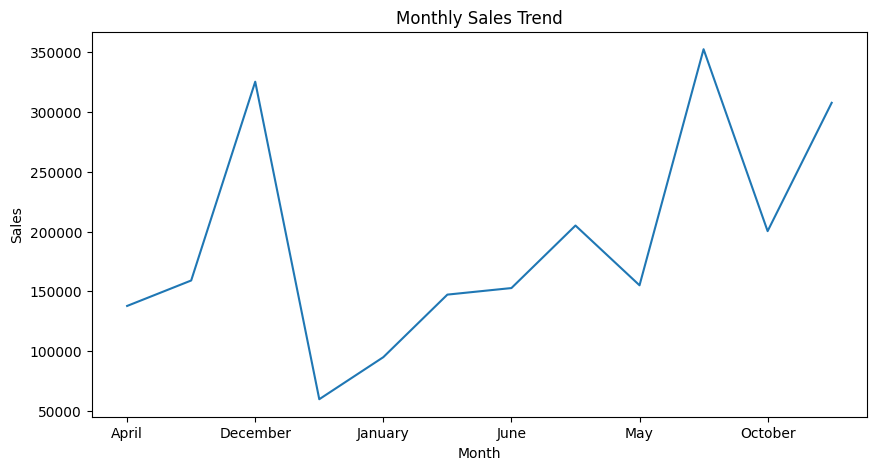

In [44]:
import matplotlib.pyplot as plt
monthly_sales = df.groupby('Order Month')['Sales'].sum()

monthly_sales.plot(kind='line', figsize=(10,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()


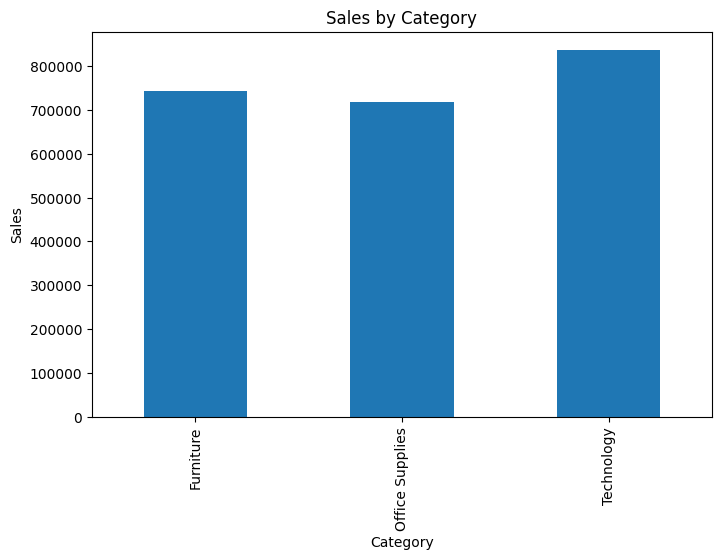

In [45]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar', figsize=(8,5))
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

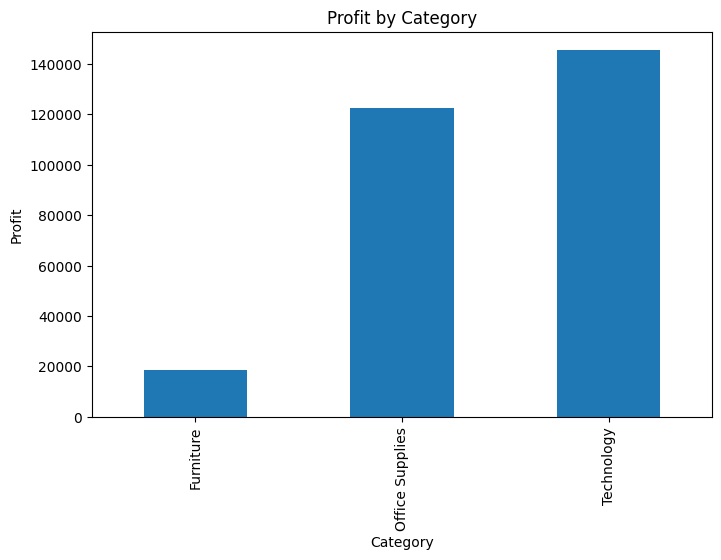

In [46]:
category_profit = df.groupby('Category')['Profit'].sum()
category_profit.plot(kind='bar', figsize=(8,5))
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

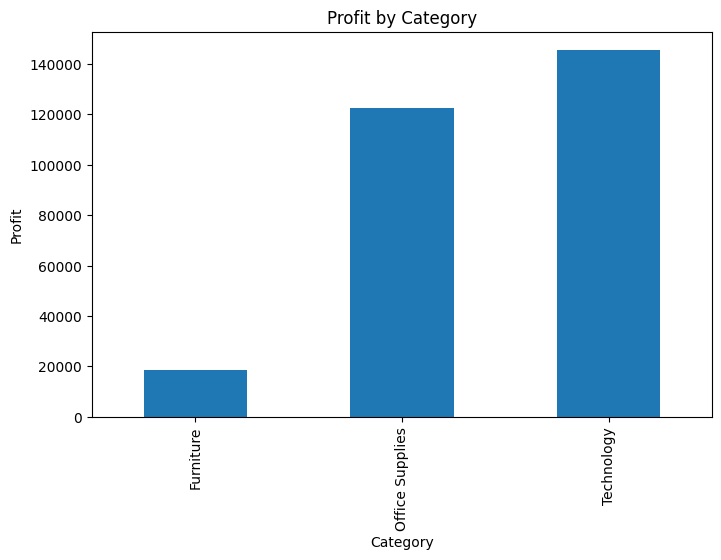

In [47]:
category_profit = df.groupby('Category')['Profit'].sum()
category_profit.plot(kind='bar', figsize=(8,5))
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

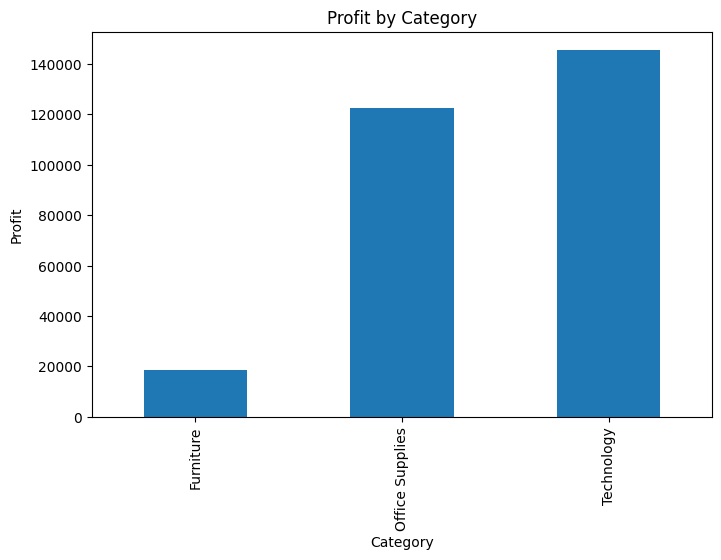

In [48]:
category_profit = df.groupby('Category')['Profit'].sum()
category_profit.plot(kind='bar', figsize=(8,5))
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

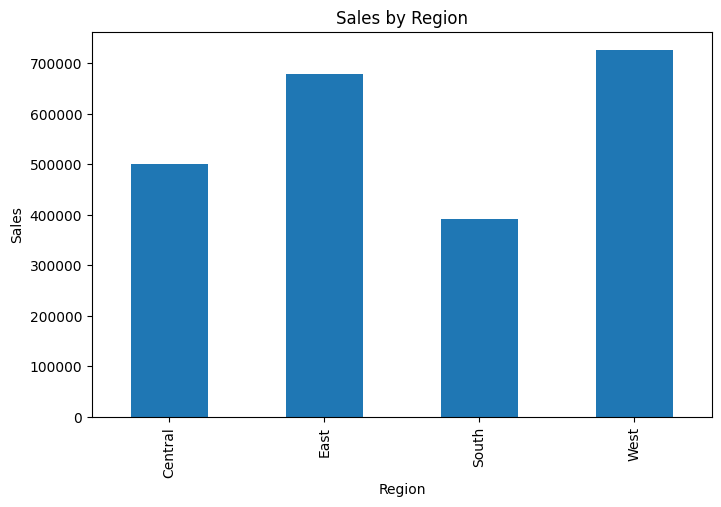

In [49]:
region_sales = df.groupby('Region')['Sales'].sum()
region_sales.plot(kind='bar', figsize=(8,5))
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()



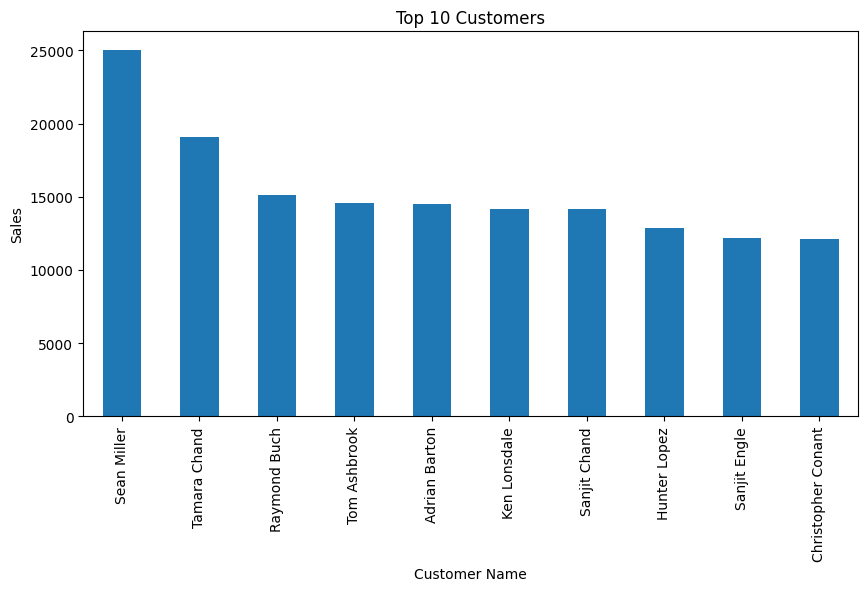

In [50]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Customers')
plt.ylabel('Sales')
plt.show()

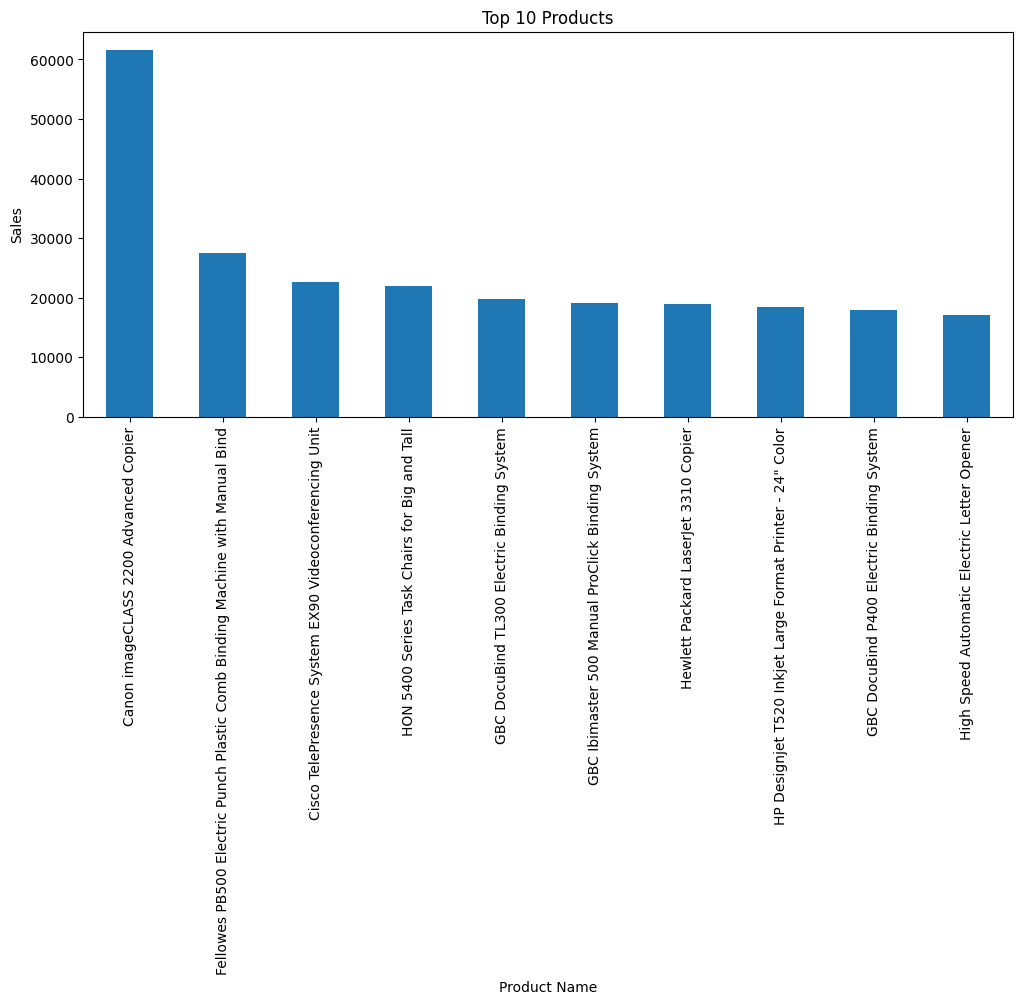

In [51]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar', figsize=(12,5))
plt.title('Top 10 Products')
plt.ylabel('Sales')
plt.show()